### Rapport du TP1 de :

- Marcelo Basso

- Carlos Maria Engler Pinto

- Oussama Blgrim

### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [1]:
import pandas as pd

df = pd.read_csv("prostate.data", sep="\t")

In [2]:
df = df.drop(labels=["Unnamed: 0", "train"], axis='columns' )

**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

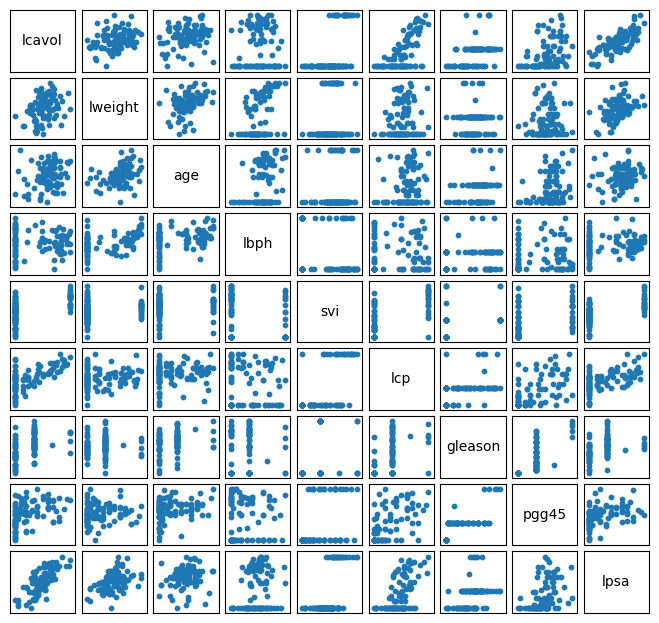

In [3]:
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    
    # shape returns the number of lines (at position 0) and columns (at position 1)
    # of the dataset
    n_vars = df.shape[1]
    
    # creates a matrix of subplots. Fig is the final image generated, while ax is 
    # the matrix with the subplots.
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    
    # defines margins
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    
    # loops over all variables (columns)
    for i in range(n_vars):
        for j in range(n_vars):
            # axij receives the current subplot
            axij = ax[i][j]
            # selects variables to coorelate
            i_name = df.columns[i]
            j_name = df.columns[j]
            # defines the axes (subplot) to which the point belong
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                # draws point
                axij.scatter(df[i_name], df[j_name], s=10)
                continue
            else:
                # writes the diagonal with the name of the variable
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

The most coorelated ones to `lcavol` seems to be `lcp` and `lpsa`. 


**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

The correlation between $X$ and $Y$ is:

$$Corr[X, Y]=\frac{Cov[X, Y]}{\sigma[X]\times\sigma[Y]}$$

In [4]:
import numpy as np

def correlation(x, y):
    # we get the [0, 1] element of the covariance matrix, which is the covariance between x and y
    covariance = np.cov(x, y, ddof=1)[0, 1]
    std_x = np.std(x, ddof=1)
    std_y = np.std(y, ddof=1)
    return covariance / (std_x * std_y)

In [5]:
# compare the correlation function with the built-in function from numpy
x = df["lcavol"]

results = []
for col in df.columns:
    results.append({
        "variable": col,
        "custom_correlation": correlation(x, df[col]),
        "df_correlation": df[col].corr(x)
    })

pandas_correlation = pd.DataFrame(results)
print("Computing the correlation between lcavol and the other variables:")
print(pandas_correlation)

Computing the correlation between lcavol and the other variables:
  variable  custom_correlation  df_correlation
0   lcavol            1.000000        1.000000
1  lweight            0.280521        0.280521
2      age            0.225000        0.225000
3     lbph            0.027350        0.027350
4      svi            0.538845        0.538845
5      lcp            0.675310        0.675310
6  gleason            0.432417        0.432417
7    pgg45            0.433652        0.433652
8     lpsa            0.734460        0.734460


The two functions give the same results.

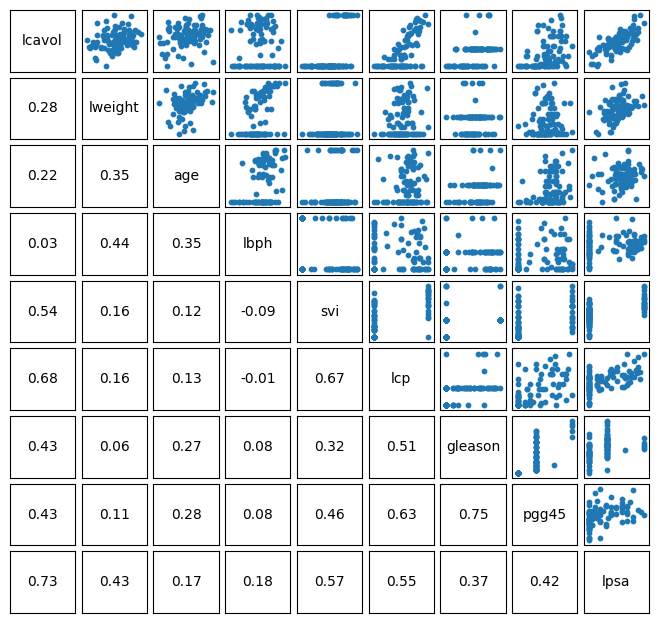

In [6]:
import matplotlib.pyplot as plt

# make a pairplot with correlation from scratch
def pairplot_with_correlation(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    
    # shape returns the number of lines (at position 0) and columns (at position 1)
    # of the dataset
    n_vars = df.shape[1]
    
    # creates a matrix of subplots. Fig is the final image generated, while ax is 
    # the matrix with the subplots.
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    
    # defines margins
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    
    # loops over all variables (columns)
    for i in range(n_vars):
        for j in range(n_vars):
            # axij receives the current subplot
            axij = ax[i][j]
            # selects variables to coorelate
            i_name = df.columns[i]
            j_name = df.columns[j]
            # defines the axes (subplot) to which the point belong
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i < j:
                # draws point
                axij.scatter(df[i_name], df[j_name], s=10)
                continue
            if i > j:
                # Compute the correlation
                corr = correlation(df[i_name], df[j_name])
                # Write the correlation in the upper left corner of the subplot
                axij.text(0.5, 0.5, f"{corr:.2f}",
                          ha='center', va='center',
                          transform=axij.transAxes)
                continue
            elif i == j:
                # writes the diagonal with the name of the variable
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot_with_correlation(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [7]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

Let $y$ represent `lcavol`, $x_1, \dots, x_6$ represent continuous variables `lweight`, `age`, `lbph`, `lcp`,	`pgg45` and `lpsa` respectively.

The multiple linear regression model for `lcavol` is:

$$ \hat{y}= \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \sum_{k}{\delta_k\mathbb{1}_{[svi = k]}} + \beta_4 x_4 + \sum_{k}{\lambda_k\mathbb{1}_{[gleason = k]}} + \beta_5 x_5 +  \beta_6 x_6 + \epsilon$$

where $\beta_0$ is the intercept, $\beta_1,\dots,\beta_6$ are the regression coefficients for continous variables, the $\delta_k$ are coefficients for each possible value $k$ of the qualitative variable `svi` and the $\lambda_k$ are coefficients for each possible value $k$ of the qualitative variable `gleason`.

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [8]:
print(df)

      lcavol   lweight  age      lbph svi       lcp gleason  pgg45      lpsa
0  -0.579818  2.769459   50 -1.386294   0 -1.386294       6      0 -0.430783
1  -0.994252  3.319626   58 -1.386294   0 -1.386294       6      0 -0.162519
2  -0.510826  2.691243   74 -1.386294   0 -1.386294       7     20 -0.162519
3  -1.203973  3.282789   58 -1.386294   0 -1.386294       6      0 -0.162519
4   0.751416  3.432373   62 -1.386294   0 -1.386294       6      0  0.371564
..       ...       ...  ...       ...  ..       ...     ...    ...       ...
92  2.830268  3.876396   68 -1.386294   1  1.321756       7     60  4.385147
93  3.821004  3.896909   44 -1.386294   1  2.169054       7     40  4.684443
94  2.907447  3.396185   52 -1.386294   1  2.463853       7     10  5.143124
95  2.882564  3.773910   68  1.558145   1  1.558145       7     80  5.477509
96  3.471966  3.974998   68  0.438255   1  2.904165       7     20  5.582932

[97 rows x 9 columns]


In [9]:
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']

- Why did we fix a `dtype` in `pd.get_dummies`?

$\hookrightarrow$ By default, ```pd.get_dummies``` creates dummy columns as bool (True/False). Setting `dtype=np.float64` forces them to be numeric (0.0/1.0), which is required for matrix operations.
- Why did we drop two columns after the encoding?

$\hookrightarrow$ This avoids the dummy variable trap (perfect multicollinearity). For a categorical variable with k levels, you only need k−1 dummy columns — the dropped category becomes the reference category.

- Why did we add a column of ones to the dataframe?

$\hookrightarrow$ For two reasonss:

1. **To include the intercept** $\beta_0$ in the model — without it, the regression is forced through the origin, which is almost always incorrect.

2. **To keep the matrix dimensions consistent** — writing $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$ requires $\mathbf{X}$ to have the same number of columns as there are parameters in $\boldsymbol{\beta}$ (including $\beta_0$). The column of ones "absorbs" the intercept into the matrix multiplication, so $\boldsymbol{\beta} = [\beta_0, \beta_1, \dots, \beta_p]^\top$ and $\mathbf{X}$ is consistently of shape $(n \times (p+1))$.

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [10]:
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()

In [11]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        20:51:53   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- For `svi`,  the coefficient `svi_1` represents the expected difference in the dependent variable between (svi = 1) and (svi = 0, reference). The same for the coefficients related to `gleason` where each one of the categories $7, 8, 9$ is compared to the reference cat $6$.
- If we did not use one hot encoding, the regression would assume that there is a linear relation between these variabbles and the output `y`, which may not be the case for categorical variables.
- `age`, `lcp`, `pgg45` and `lpsa` have low p-values so they are stastically significant variables. One-hot encoding was necessary to avoid incorrect linear assumptions about Gleason score.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [12]:
results.conf_int()

,0,1
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


the variables for which the confidence intervals do not contain $0$ therefor they are stastically significant at a level of $5%$ are `age`, `lcp`, `pgg45` and `lpsa`. Which is the same result that we got by comparing the p-values and keeping only those close to $0$.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [13]:
results.pvalues

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64

The variable `lpsa` has a statistically significant and positive effect on the dependent variable. The hypothesis test strongly rejects the null hypothesis of no effect ($p < 10^{-7}$), and the 95% confidence interval [0.3705, 0.7287] confirms that the true coefficient is positive and well separated from zero.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

Under the Gaussian linear regression model $Y = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, the OLS estimator is given by:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

and follows the distribution $\hat{\boldsymbol{\beta}} \sim \mathcal{N}(\boldsymbol{\beta},\, \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1})$.

Since $\sigma^2$ is unknown, we estimate it with:

$$\hat{\sigma}^2 = \frac{1}{N}\|\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}\|^2 \qquad \text{with} \qquad \mathbb{E}[\hat{\sigma}^2] = \frac{N-(p+1)}{N}\sigma^2$$

The standard error of each coefficient $\hat{\beta}_i$ is:

$$\widehat{\text{se}}[\hat{\beta}_i] = \sqrt{\hat{\sigma}^2 (\mathbf{X}^\top\mathbf{X})^{-1}_{i+1,\,i+1}}$$

To test whether each predictor is statistically significant, we use the hypothesis test $\mathcal{H}_0 : \beta_i = 0$ vs $\mathcal{H}_1 : \beta_i \neq 0$, with test statistic:

$$\hat{T}_i = \frac{\hat{\beta}_i}{\widehat{\text{se}}[\hat{\beta}_i]} \sim t_{N-p-1}$$

and two-sided $p$-value $p_i = \text{Prob}(|\hat{T}_i| > t_{\alpha/2} \mid \mathcal{H}_0)$. If $p_i < \alpha$, we reject $\mathcal{H}_0$.

In [14]:
import numpy as np
from scipy import stats

def linear_regression_from_scratch(X, y):
    X_arr = X.to_numpy() # convert the dataframe to a numpy array for matrix operations
    y_arr = y.to_numpy() # convert the target variable to a numpy array
    N, p_plus_1 = X_arr.shape

    # Estimate coefficients: β̂ = (XᵀX)⁻¹Xᵀy
    # @ is the matmult
    '''np.linalg.solve(A, b) solves the linear equation Ax = b for x,
    where A is a square matrix and b is a vector or matrix.
    Here we gave it XᵀX as A and Xᵀy as b, so it will solve for β in the equation (XᵀX)β = Xᵀy.'''

    beta = np.linalg.solve(X_arr.T @ X_arr, X_arr.T @ y_arr)

    # Residuls and variance (unbiased: divide by N - (p+1))
    residuals = y_arr - X_arr @ beta
    # since the norm squared of the residuals is given by residualsᵀ residuals, we can compute σ̂² as shown below
    # Formula: σ̂² = (residualsᵀ residuals) / (N - (p + 1))
    sigma2 = (residuals.T @ residuals) / (N - p_plus_1)

    # Standard errors from diagonal of σ̂²(XᵀX)⁻¹
    se = np.zeros(p_plus_1)
    for i in range(p_plus_1):
        se[i] = np.sqrt(sigma2 * np.linalg.inv(X_arr.T @ X_arr)[i, i])

    # t-statistics and two-sided p-values with N-p-1 degrees of freedom
    t_stats = beta / se
    # stats.t is the t student distribution, we get its cumulative dist function (cdf) using stats.t.cdf, df is the degree of freedom
    # here the number of degrees of freedom is N - p - 1
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=N - p_plus_1))

    new_df = pd.DataFrame({
        "variable": X.columns,
        "beta": beta,
        "se": se,
        "t_stat": t_stats,
        "p_value": p_values
    })

    return new_df

print(linear_regression_from_scratch(X, y))

     variable      beta        se    t_stat       p_value
0     lweight -0.011246  0.211453 -0.053185  9.577075e-01
1         age  0.024782  0.011241  2.204628  3.014993e-02
2        lbph -0.104200  0.058209 -1.790107  7.695609e-02
3         lcp  0.402760  0.085074  4.734252  8.577858e-06
4       pgg45 -0.009444  0.004540 -2.080263  4.047741e-02
5        lpsa  0.549573  0.090093  6.100047  2.939241e-08
6       svi_1 -0.220419  0.256351 -0.859833  3.922717e-01
7   gleason_7  0.311676  0.215268  1.447850  1.512950e-01
8   gleason_8 -0.710588  0.758827 -0.936429  3.516744e-01
9   gleason_9  0.790135  0.487510  1.620755  1.087313e-01
10  intercept -1.406654  0.874455 -1.608606  1.113676e-01


$\hookrightarrow$ `Comparing our function to the built-in one, we see that we get the same results.

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

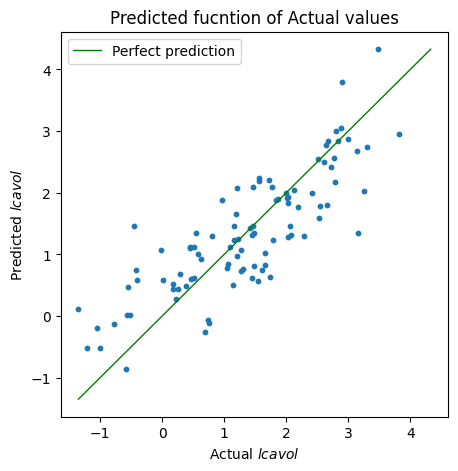

In [15]:
# Using statsmodels
predictions = results.get_prediction(X).predicted_mean

fig, ax = plt.subplots(figsize=(5, 5))
#using size of 10 for the points to make them smaller and more visible
ax.scatter(y, predictions, s=10)

# Perfect prediction line
lims = [min(y.min(), predictions.min()), max(y.max(), predictions.max())]
ax.plot(lims, lims, 'g-', linewidth=1, label="Perfect prediction")

ax.set_xlabel("Actual $lcavol$")
ax.set_ylabel("Predicted $lcavol$")
ax.set_title("Predicted fucntion of Actual values")
ax.legend()
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

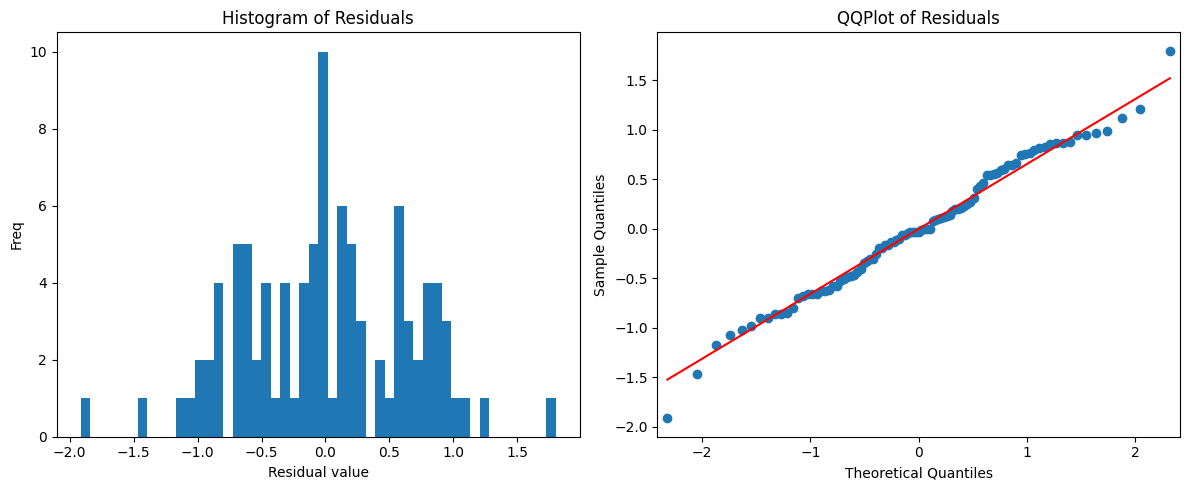

Residual Sum of Squares: 41.814068608045346


In [16]:
# Plot histogram of residuals

# we can access the residual in two different ways:
# `resid = y - predictions`
# `results.resid`

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# divides values into 50 bins
ax1.hist(results.resid, bins=50)
ax1.set_title("Histogram of Residuals")
ax1.set_xlabel("Residual value")
ax1.set_ylabel("Freq")

# Plot qqplot
sm.qqplot(results.resid, line='s', ax=ax2)
ax2.set_title("QQPlot of Residuals")

# Adjust the padding between and around subplots.
plt.tight_layout()
plt.show()

print(f"Residual Sum of Squares: {results.ssr}")

$\hookrightarrow$ `Based on the histogram generated, we can see a clear _bell shaped_ curve centered at zero, indicating a normal distribution. The QQPlot confirms the hypothesis, given that the points sit almost perfeclty in the diagonal line.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

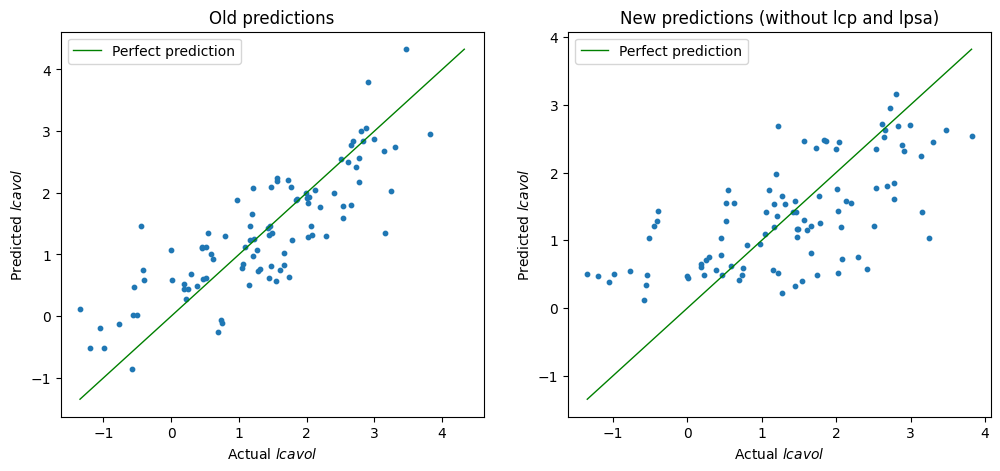

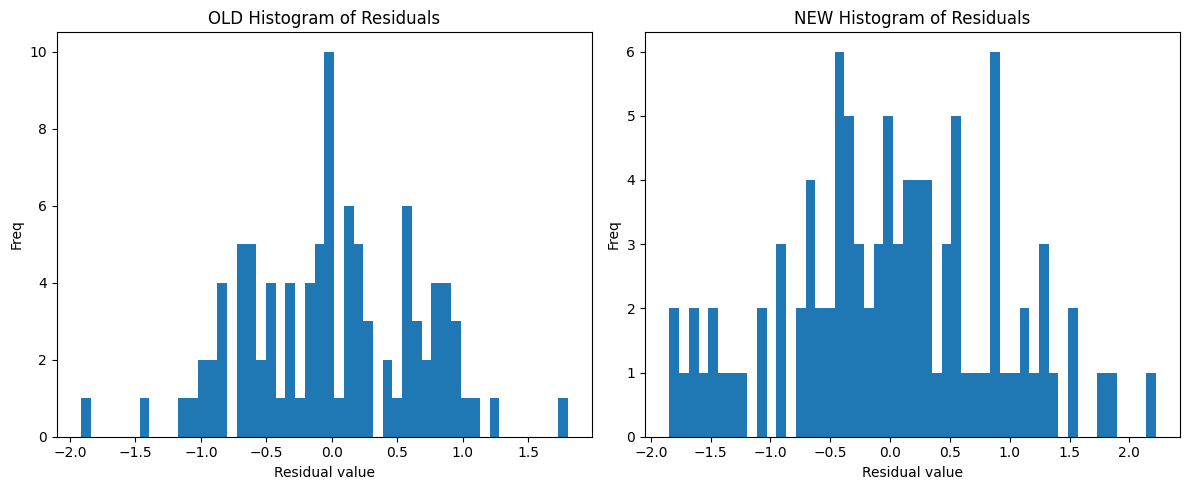

NEW Residual Sum of Squares: 75.65323290824037


In [17]:
X_new = X.drop(columns=["lpsa", "lcp"])
model_new = sm.OLS(y, X_new)
results_new = model_new.fit()

# ------------------ Predictions ------------------
predictions_new = results_new.get_prediction(X_new).predicted_mean
fig, (ax3, ax4) = plt.subplots(1, 2,figsize=(12, 5))

ax3.scatter(y, predictions, s=10)
lims = [min(y.min(), predictions.min()), max(y.max(), predictions.max())]
ax3.plot(lims, lims, 'g-', linewidth=1, label="Perfect prediction")
ax3.set_xlabel("Actual $lcavol$")
ax3.set_ylabel("Predicted $lcavol$")
ax3.set_title("Old predictions")
ax3.legend()

lims = [min(y.min(), predictions_new.min()), max(y.max(), predictions_new.max())]
ax4.plot(lims, lims, 'g-', linewidth=1, label="Perfect prediction")
ax4.scatter(y, predictions_new, s=10)
ax4.set_xlabel("Actual $lcavol$")
ax4.set_ylabel("Predicted $lcavol$")
ax4.set_title("New predictions (without lcp and lpsa)")
ax4.legend()
plt.show()

# ------------------ Histogram ------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(results.resid, bins=50)
ax1.set_title("OLD Histogram of Residuals")
ax1.set_xlabel("Residual value")
ax1.set_ylabel("Freq")

ax2.hist(results_new.resid, bins=50)
ax2.set_title("NEW Histogram of Residuals")
ax2.set_xlabel("Residual value")
ax2.set_ylabel("Freq")

# Adjust the padding between and around subplots.
plt.tight_layout()
plt.show()

print(f"NEW Residual Sum of Squares: {results_new.ssr}")

**What happens if predictors lpsa and lcp are removed from the multiple linear regression model?**

$\hookrightarrow$ Given the fact that `lpsa` and `lcp` are important predictors for our regression, it is expected that the error (RSS) increases, which indeed happens (from 41.814 to 75.653), showing that the model has less accuracy in its predictions. It's also possible to see that the _bell shape_ of the histogram of residuals changed away from a usual normal distribution shape.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

In [18]:
from itertools import combinations

def linreg_subset(size):
    """
    Given a _size_, returns list with results from ordinary least squares (OLS)
    and given subset for every possible combination of predictors of size _size_.
    """
    
    ssr_list = []
    combs = combinations(df.drop(columns=['lcavol']), size)
    # adds intercept to the list of predictors
    combs = map(lambda x: x + ('intercept',), combs)
    
    for sub_p in combs:
        # creates DataFrame with subset of predictors (real predictors + intercept)
        real_p = [i for i in list(sub_p) if i != 'intercept']
        new_df = df[real_p].copy()
    
        # appends intercept as float
        new_df['intercept'] = 1.0
        # treats categorical predictors
        new_df = pd.get_dummies(new_df, dtype=np.float64)
        if ('svi' in sub_p):
            new_df = new_df.drop(columns=['svi_0'])
        if ('gleason' in sub_p):
            new_df = new_df.drop(columns=['gleason_6'])

        # runs linear regression
        model = sm.OLS(y, new_df)
        results = model.fit()
    
        # appends results to the list
        ssr_list.append({
            'results': results,
            'sub_p': [i for i in list(sub_p) if i != 'intercept']
        })

    return ssr_list

# from the list of results with subsets size=2, select the min ssr
best_model = min(linreg_subset(2), key=lambda x: x['results'].ssr)
print(f"Best model has the following predictors {best_model['sub_p']} with SSR: {best_model['results'].ssr}")

Best model has the following predictors ['lcp', 'lpsa'] with SSR: 47.27809728978648


**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

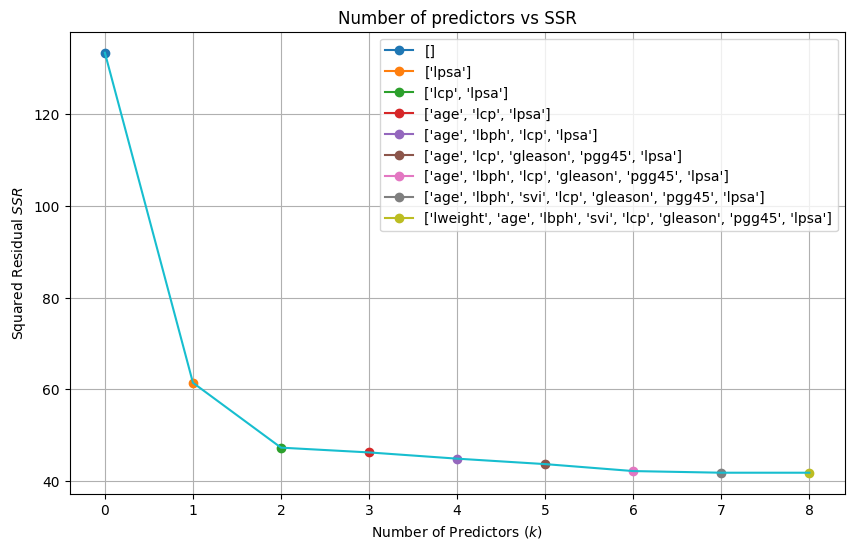

In [19]:
best_models = []

for j in range(0, 9):
    best_models.append(min(linreg_subset(j), key=lambda x: x['results'].ssr))
    #print(f"k={j}, predictors: {best_models[j]['sub_p']}, with ssr={best_models[j]['results'].ssr}")

plt.figure(figsize=(10, 6))
for i, b in enumerate(best_models):
    plt.plot(i, b['results'].ssr, marker='o', label=f"{b['sub_p']}")

# draw line connecting points
plt.plot(range(0, 9), [b['results'].ssr for i, b in enumerate(best_models)])
plt.xlabel('Number of Predictors ($k$)')
plt.ylabel('Squared Residual $SSR$')
plt.title('Number of predictors vs SSR')
plt.grid(True)
plt.legend()
plt.show()

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

$\hookrightarrow$ **NO**. As we increase the number of predictors, the complexity of the estimatives also increases, which makes the Sum of Squared Residuals go down. This *may seem like a good think*, however, that tends to overcomplicate the model based only on the training dataset. 

As we increase the complexity, we run the risk of **overfitting** the model, making it perform very well with the training data, but lose generality and therefore perform worse with testing/real data.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.